# Combining script for making figure 1

This script combined Figure 1 of SBR data and inoculum/proprotions data.

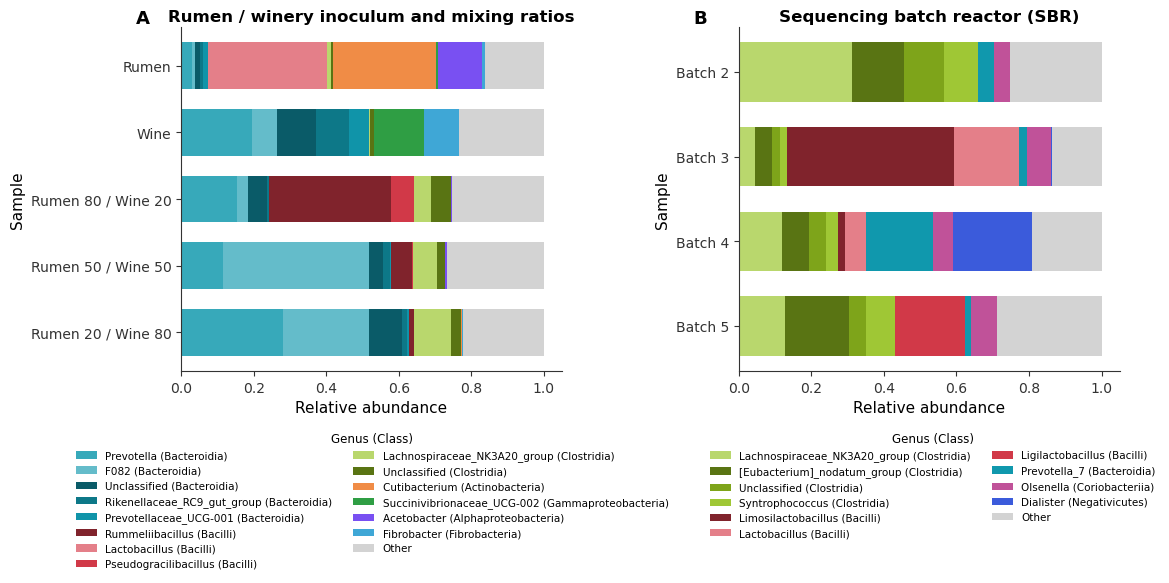

In [5]:
import pickle
from anyio import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

with open("/Users/hector/git/bioreactor-microbiome-functional-inference/results/results_1_checked/figures_inocula_proportions_combined/composition_export_inocula_proportions.pkl", "rb") as f:
    inocula_d = pickle.load(f)
with open("/Users/hector/git/bioreactor-microbiome-functional-inference/results/results_3_checked/SVR/dada2_trimmed_F275_R245/figures/composition_export_SBR.pkl", "rb") as f:
    sbr_d = pickle.load(f)

fig_dir = "/Users/hector/git/bioreactor-microbiome-functional-inference/results/results_1_checked/figures_inocula_proportions_combined"
# Figure sizing (inches). Bioresource Technology / Springer full text width
#      is ~17.5 cm (~6.9 in); Nature double-column is ~183 mm (~7.2 in). These
#      sizes work cleanly across both without redesigning each panel. 
FIGSIZE_BAR      = (7.2, 4.3)   # horizontal stacked bar charts (composition, function, bioproduct)
FIGSIZE_HEATMAP  = (7.2, 5.2)   # Spearman correlation heatmaps
FIGSIZE_PCA      = (4.0, 3.8)   # single-column ordination plot



def save_fig(fig_dir, name, fig=None):
    """Save a figure in the three formats journals commonly require:
    PDF (vector, primary submission format), TIFF at 600 dpi (raster
    requirement for combination art in most journals), and PNG at 300 dpi
    (quick preview / supplementary use). Uses tight bounding boxes throughout.
    """
    fig = fig or plt.gcf()
    fig_dir = Path(fig_dir)
    fig.savefig(fig_dir / f"{name}.pdf", bbox_inches="tight", pad_inches=0.05)
    fig.savefig(fig_dir / f"{name}.tiff", dpi=600, bbox_inches="tight", pad_inches=0.05)
    fig.savefig(fig_dir / f"{name}.png", dpi=300, bbox_inches="tight", pad_inches=0.05)


def style_axes(ax=None):
    """Apply consistent minimal-chrome styling to a bar/scatter axes."""
    ax = ax or plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#333333")
    ax.spines["bottom"].set_color("#333333")
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(width=0.8, colors="#333333")
    return ax


n_rows_max = max(len(inocula_d["df_pivot"]), len(sbr_d["df_pivot"]))
fig_height = max(FIGSIZE_BAR[1], 0.8 * n_rows_max + 2.2)

fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE_BAR[0] * 1.6, fig_height))

panel_titles = ["Rumen / winery inoculum and mixing ratios", "Sequencing batch reactor (SBR)"]

for ax, d, letter, title in zip(axes, [inocula_d, sbr_d], ["A", "B"], panel_titles):
    left = None
    for col in d["df_pivot"].columns:
        ax.barh(
            d["df_pivot"].index, d["df_pivot"][col], left=left,
            label=d["display_labels"][col],
            color=d["taxa_colors"].get(col, "lightgray"),
            height=0.7,
        )
        left = d["df_pivot"][col] if left is None else left + d["df_pivot"][col]
    ax.text(-0.12, 1.05, letter, transform=ax.transAxes,
            fontsize=13, fontweight="bold", va="top", ha="left")
    ax.set_xlabel("Relative abundance", fontsize=11)
    ax.set_ylabel("Sample", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=4)
    ax.tick_params(axis="both", labelsize=10)
    style_axes(ax)

axes[0].legend(bbox_to_anchor=(-0.3, -0.15), loc="upper left", fontsize=7.5,
               title="Genus (Class)", title_fontsize=8.5, ncol=2, frameon=False)
axes[1].legend(bbox_to_anchor=(-0.1, -0.15), loc="upper left", fontsize=7.5,
               title="Genus (Class)", title_fontsize=8.5, ncol=2, frameon=False)

plt.tight_layout()
save_fig(fig_dir, "combined_composition_panel")
plt.show()